# Importing the relevant libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

# Data Preprocessing

### Importing the Database

In [111]:
df = pd.read_csv("/content/ml_datasource.csv")

In [112]:
df.shape

(17761, 8)

In [113]:
df.head()

,student_country,days_on_platform,minutes_watched,courses_started,practice_exams_started,practice_exams_passed,minutes_spent_on_exams,purchased
0,US,288,358.1,1,2,2,15.81,0
1,SG,260,1.7,1,1,0,16.00,0
2,TR,260,22.4,1,1,0,0.93,0
3,KE,259,18.8,1,1,1,14.63,0
4,IN,259,118.0,2,2,1,16.48,0


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17761 entries, 0 to 17760
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_country         17752 non-null  object 
 1   days_on_platform        17761 non-null  int64  
 2   minutes_watched         17761 non-null  float64
 3   courses_started         17761 non-null  int64  
 4   practice_exams_started  17761 non-null  int64  
 5   practice_exams_passed   17761 non-null  int64  
 6   minutes_spent_on_exams  17761 non-null  float64
 7   purchased               17761 non-null  int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 1.1+ MB


In [115]:
data = df.copy()

### EDA

### Distributions

array([[<Axes: title={'center': 'days_on_platform'}>,
        <Axes: title={'center': 'minutes_watched'}>,
        <Axes: title={'center': 'courses_started'}>],
       [<Axes: title={'center': 'practice_exams_started'}>,
        <Axes: title={'center': 'practice_exams_passed'}>,
        <Axes: title={'center': 'minutes_spent_on_exams'}>],
       [<Axes: title={'center': 'purchased'}>, <Axes: >, <Axes: >]],
      dtype=object)

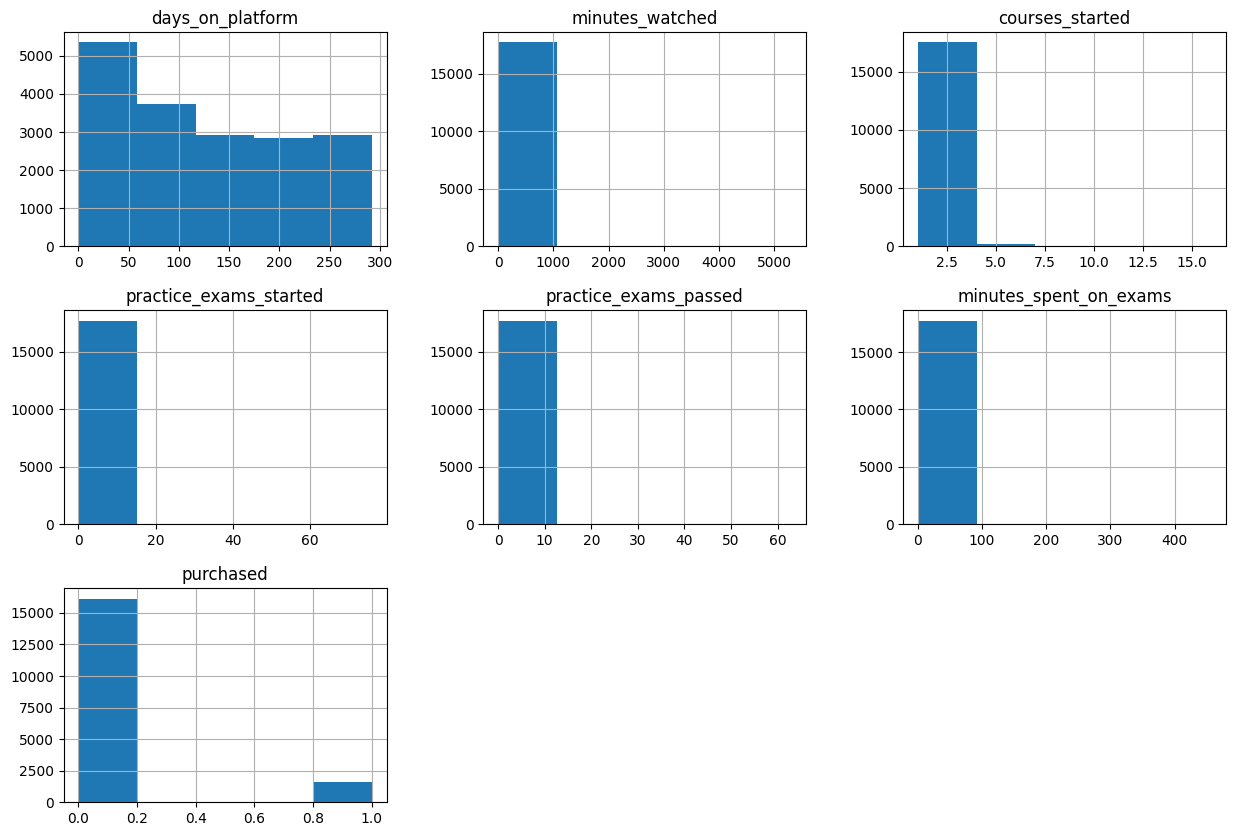

In [116]:
#Checking Distribution
df.hist(figsize=(15, 10), bins=5)

### Removing Outliers

In [117]:
"""
this function removes outliers from the dataset
it takes one argument which is the dataframe variable
Based on the distribution plots, we will remove outliers from all columns
the following syntax will be used to adjust the values inside the columns
df = df[df['column_name'] >= 0
"""
def removing_outliers(data):
    data = data[data['minutes_watched'] <= 1000]
    data = data[data["courses_started"] <= 10]
    data = data[data["practice_exams_started"] <= 10]
    data = data[data["minutes_spent_on_exams"] < 40]
    return data

In [118]:
df1 = removing_outliers(df)

In [119]:
df1

,student_country,days_on_platform,minutes_watched,courses_started,practice_exams_started,practice_exams_passed,minutes_spent_on_exams,purchased
0,US,288,358.1,1,2,2,15.81,0
1,SG,260,1.7,1,1,0,16.00,0
2,TR,260,22.4,1,1,0,0.93,0
3,KE,259,18.8,1,1,1,14.63,0
4,IN,259,118.0,2,2,1,16.48,0
...,...,...,...,...,...,...,...,...
17756,EG,0,0.8,1,0,0,0.00,0
17757,IN,0,0.1,1,0,0,0.00,0
17758,CM,0,7.8,1,0,0,0.00,0
17759,CA,0,10.4,1,0,0,0.00,0


array([[<Axes: title={'center': 'days_on_platform'}>,
        <Axes: title={'center': 'minutes_watched'}>,
        <Axes: title={'center': 'courses_started'}>],
       [<Axes: title={'center': 'practice_exams_started'}>,
        <Axes: title={'center': 'practice_exams_passed'}>,
        <Axes: title={'center': 'minutes_spent_on_exams'}>],
       [<Axes: title={'center': 'purchased'}>, <Axes: >, <Axes: >]],
      dtype=object)

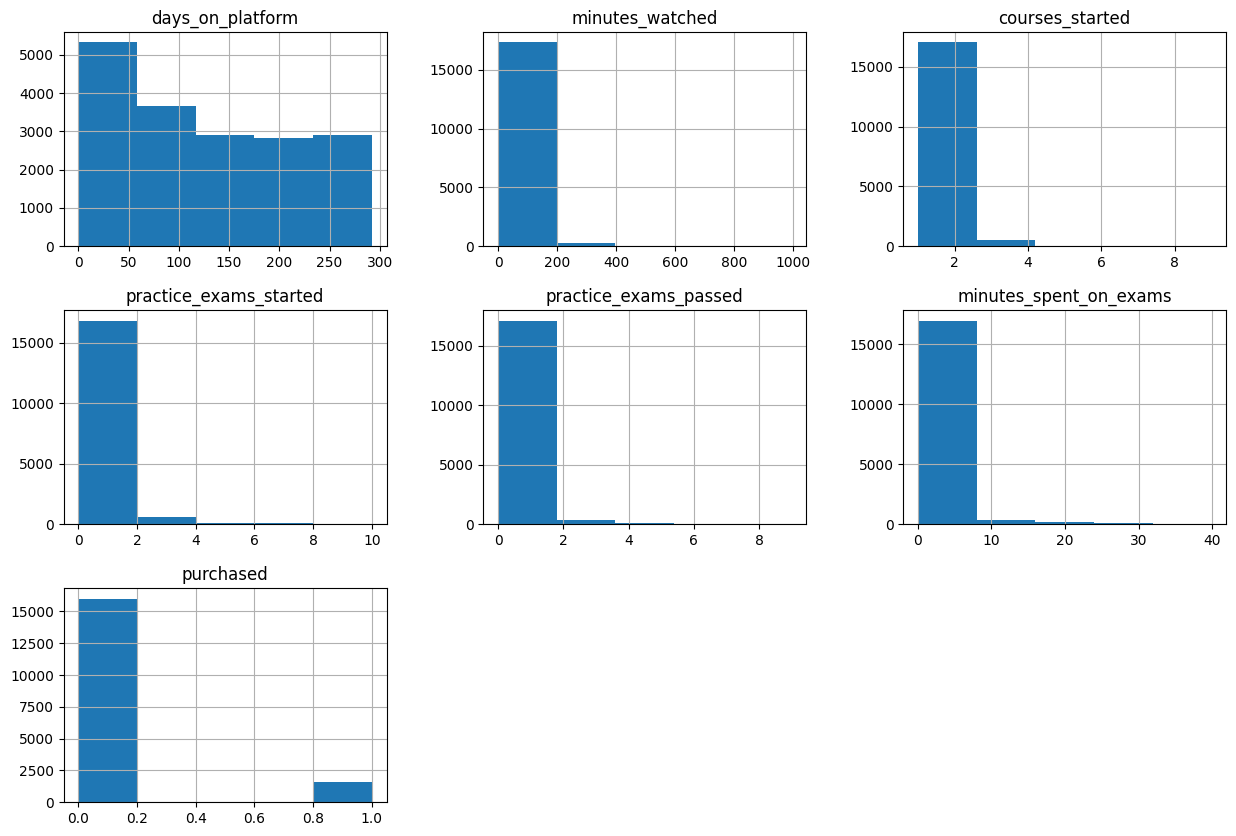

In [120]:
#Checking Distribution after removing outliers
df1.hist(figsize=(15, 10), bins=5)

### Checking for Multicollinearity

In [121]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [122]:
numerical_col = df1.select_dtypes(include=['number'])

In [123]:
vif_data = pd.DataFrame()
vif_data["Feature"] = df1.select_dtypes(include=['number']).columns
vif_data["VIF"] = [variance_inflation_factor(df1.select_dtypes(include=['number']).values, i)
                   for i in range(df1.select_dtypes(include=['number']).shape[1])]

# Display results sorted by VIF
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data)

                  Feature        VIF
3  practice_exams_started  10.206124
4   practice_exams_passed   7.843486
2         courses_started   3.505793
5  minutes_spent_on_exams   3.383208
0        days_on_platform   2.495317
1         minutes_watched   1.817292
6               purchased   1.229056


In [124]:
corr = numerical_col.corr()

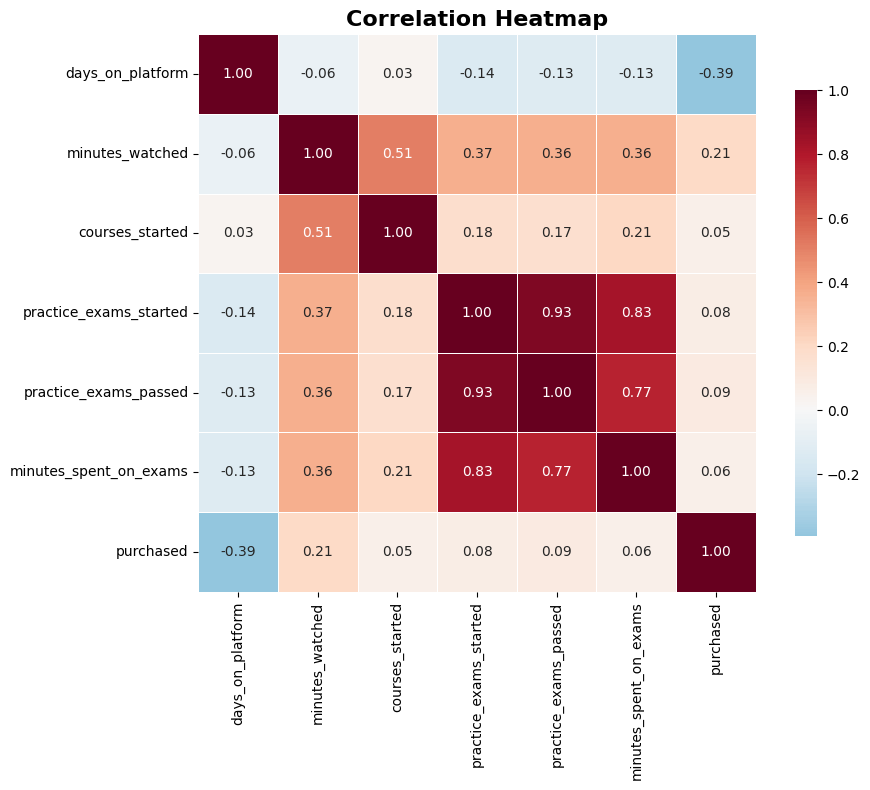

In [125]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [126]:
"""
as the VIF of the [practice exams started and the practice exams passed]
exceeds 5, we will remove the 2 columns to prevent multicollinearity
also, from the Correlation matrix that some features are correlated
"""
df1.drop(columns=["practice_exams_started"],axis=1,inplace=True)

In [127]:
df1

,student_country,days_on_platform,minutes_watched,courses_started,practice_exams_passed,minutes_spent_on_exams,purchased
0,US,288,358.1,1,2,15.81,0
1,SG,260,1.7,1,0,16.00,0
2,TR,260,22.4,1,0,0.93,0
3,KE,259,18.8,1,1,14.63,0
4,IN,259,118.0,2,1,16.48,0
...,...,...,...,...,...,...,...
17756,EG,0,0.8,1,0,0.00,0
17757,IN,0,0.1,1,0,0.00,0
17758,CM,0,7.8,1,0,0.00,0
17759,CA,0,10.4,1,0,0.00,0


In [26]:
num_col = df1.select_dtypes(include=['number'])
corr_after = num_col.corr()

In [128]:
vif_data = pd.DataFrame()
vif_data["Feature"] = df1.select_dtypes(include=['number']).columns
vif_data["VIF"] = [variance_inflation_factor(df1.select_dtypes(include=['number']).values, i)
                   for i in range(df1.select_dtypes(include=['number']).shape[1])]

# Display results sorted by VIF
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data)

                  Feature       VIF
2         courses_started  3.499490
4  minutes_spent_on_exams  2.643139
3   practice_exams_passed  2.594284
0        days_on_platform  2.493221
1         minutes_watched  1.816679
5               purchased  1.228519


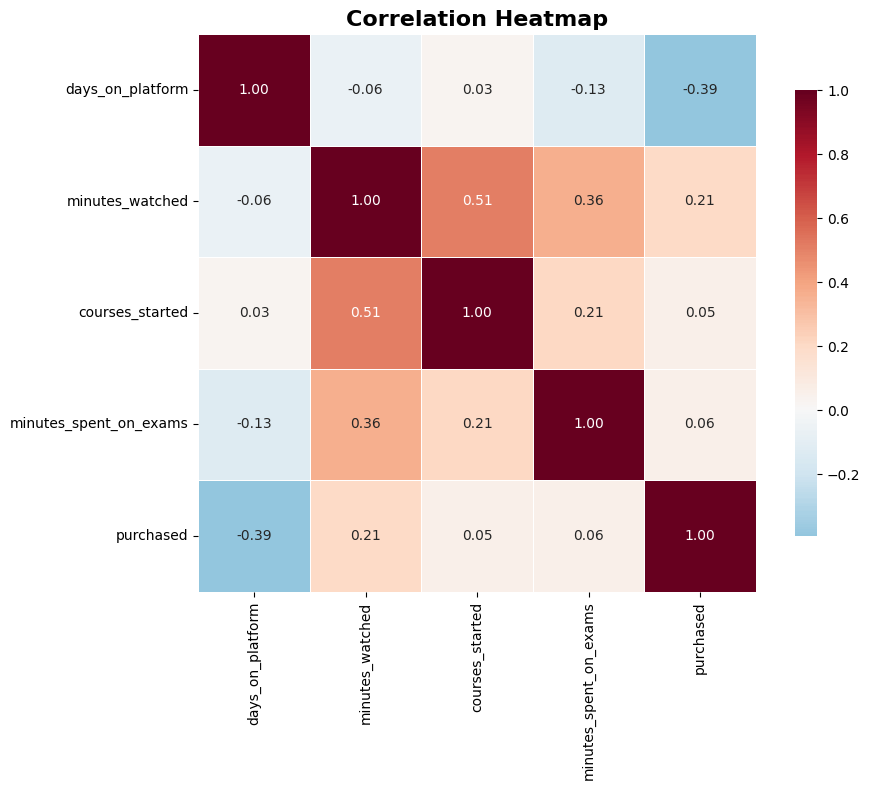

In [129]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_after,
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Dealing with NaN Values

In [130]:
"""
there is no missing in the dataset, the pandas library read the 'NA' as NAN which is panda's way to say it is missing
the goal is to correct it manually by chaning NA to NAM, deleting or imputing with mode is a wrong handling method
"""

"\nthere is no missing in the dataset, the pandas library read the 'NA' as NAN which is panda's way to say it is missing\nthe goal is to correct it manually by chaning NA to NAM, deleting or imputing with mode is a wrong handling method\n"

In [131]:
df.isnull().sum()

,0
student_country,9
days_on_platform,0
minutes_watched,0
courses_started,0
practice_exams_started,0
practice_exams_passed,0
minutes_spent_on_exams,0
purchased,0


In [132]:
df1.fillna(value="NAM",inplace=True)

### Splitting the Data

In [133]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df1.drop('purchased', axis=1)
y = df1['purchased']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [134]:
X_test.shape

(3525, 6)

### Encoding the Data

In [135]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=170)

# Encode specific column
X_train["student_country_enc"] = enc.fit_transform(X_train[["student_country"]])
X_test["student_country_enc"] = enc.transform(X_test[["student_country"]])



In [136]:
X_test

,student_country,days_on_platform,minutes_watched,courses_started,practice_exams_passed,minutes_spent_on_exams,student_country_enc
13519,AR,66,10.6,1,0,0.00,5.0
14364,TR,55,0.6,1,0,0.00,148.0
104,PK,123,17.7,1,0,16.00,120.0
12692,IT,77,57.4,1,0,0.00,73.0
325,AZ,106,71.6,3,1,5.57,9.0
...,...,...,...,...,...,...,...
14545,GH,51,0.2,1,0,0.00,56.0
10684,NG,121,1.0,1,0,0.00,110.0
8273,PL,165,4.8,2,0,0.00,121.0
2369,CA,1,116.9,1,0,0.00,27.0


In [137]:
#Dropping the student country code
X_train.drop(columns=["student_country"],axis=True,inplace=True)
X_test.drop(columns=["student_country"],axis=True,inplace=True)

# Creating a Logistic Regression Model

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

In [139]:
# Initialize and train the model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


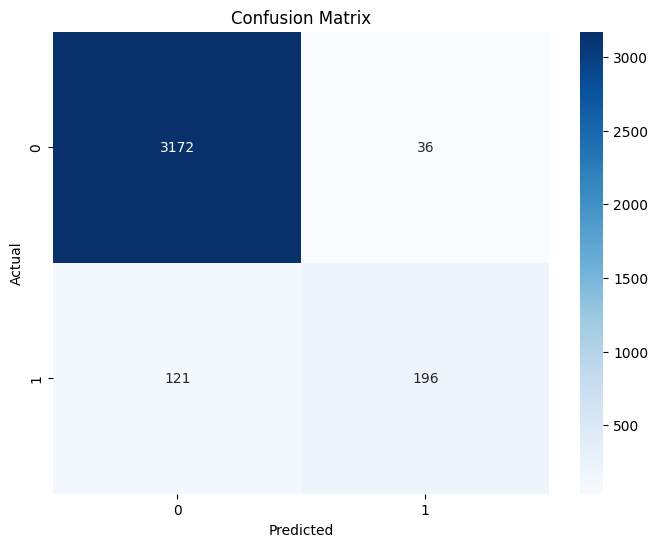

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      3208
           1       0.84      0.62      0.71       317

    accuracy                           0.96      3525
   macro avg       0.90      0.80      0.84      3525
weighted avg       0.95      0.96      0.95      3525

Accuracy: 0.9555


In [140]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Accuracy score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

In [141]:
import statsmodels.api as sm

# Fit logistic regression
logit_model = sm.Logit(y_train, X_train) # Changed X and y to X_train and y_train
result = logit_model.fit()

# Get pseudo R-squared
print(f"Pseudo R-squared: {result.prsquared}")

Optimization terminated successfully.
         Current function value: 0.152511
         Iterations 10
Pseudo R-squared: 0.5060042494401316


# Creating a K-Nearest Neighbors Model

In [142]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [143]:
neighbours = range(1,51)
param_grid_knn = {
    'n_neighbors': neighbours,
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [144]:
grid_search_knn = GridSearchCV(estimator=KNeighborsClassifier(),scoring = "accuracy", param_grid= param_grid_knn , cv=5, n_jobs=-1)

In [145]:
knn_clf = grid_search_knn.fit(X_train, y_train)

In [146]:
knn_clf.best_params_

{'metric': 'manhattan', 'n_neighbors': 17, 'weights': 'uniform'}

In [147]:
knn_clf.best_score_

np.float64(0.9613475177304963)

In [148]:
y_test_pred_knn = knn_clf.predict(X_test)

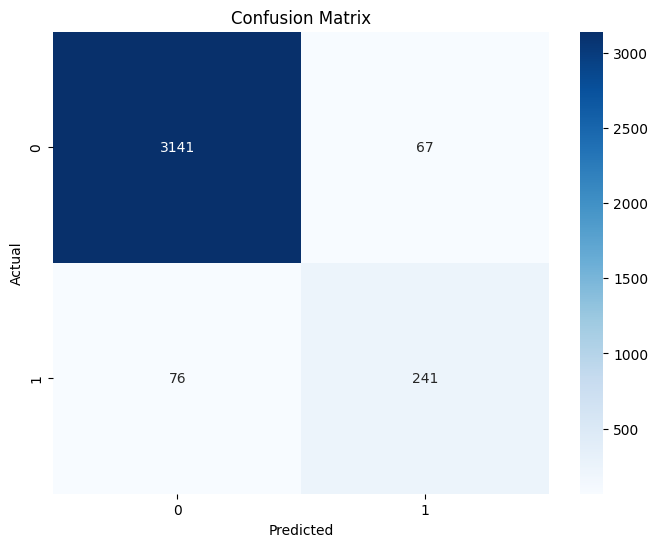

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3208
           1       0.78      0.76      0.77       317

    accuracy                           0.96      3525
   macro avg       0.88      0.87      0.87      3525
weighted avg       0.96      0.96      0.96      3525

Accuracy: 0.9594


In [149]:
# Confusion Matrix
cm_KNN = confusion_matrix(y_test, y_test_pred_knn)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_KNN, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_test_pred_knn))

# Accuracy score

accuracy = accuracy_score(y_test, y_test_pred_knn)
print(f"Accuracy: {accuracy:.4f}")

# Creating a Decision Trees Model

In [52]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [53]:
ccp_alphas = np.array([0,0.001,0.002,0.003,0.004,0.005])

In [54]:
param_grid_dt = {
    'ccp_alpha': ccp_alphas
}


grid_search_DT = GridSearchCV(
    DecisionTreeClassifier(random_state=365),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [55]:
DT_clf = grid_search_DT.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [56]:
y_pred_DT = DT_clf.predict(X_test)

In [62]:
print("Best ccp_alpha:", DT_clf.best_params_['ccp_alpha'])
print("Best accuracy:", DT_clf.best_score_)

Best ccp_alpha: 0.002
Best accuracy: 0.9622695035460993


In [63]:
ccp_alpha = DT_clf.best_params_['ccp_alpha']

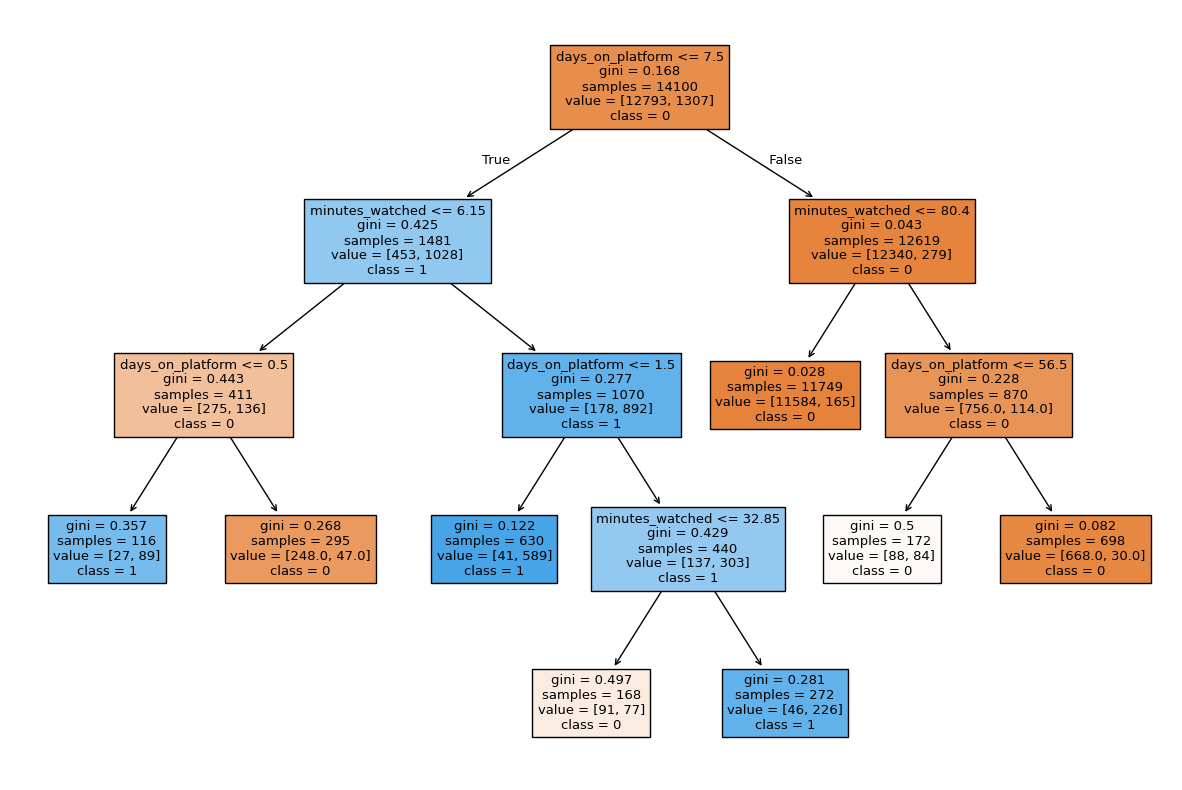

In [57]:
plt.figure(figsize=(15, 10))
plot_tree(DT_clf.best_estimator_,
          filled=True,
          feature_names=X_train.columns,
          class_names=[str(c) for c in DT_clf.classes_]
          )
plt.show()

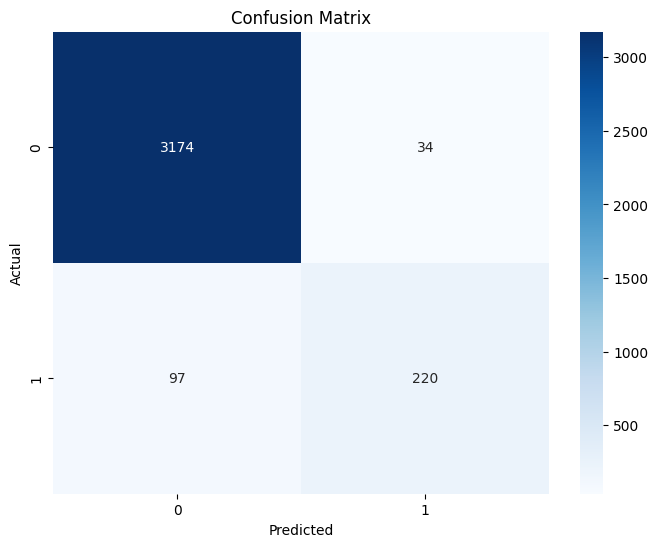

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3208
           1       0.87      0.69      0.77       317

    accuracy                           0.96      3525
   macro avg       0.92      0.84      0.88      3525
weighted avg       0.96      0.96      0.96      3525

Accuracy: 0.9628


In [58]:
# Confusion Matrix
cm_DT = confusion_matrix(y_test, y_pred_DT)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_DT, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_DT))

# Accuracy score

accuracy = accuracy_score(y_test, y_pred_DT)
print(f"Accuracy: {accuracy:.4f}")

# Creating a Random Forests Model

In [81]:
from sklearn.ensemble import RandomForestClassifier

In [82]:
RF_clf = RandomForestClassifier(random_state=365, ccp_alpha =ccp_alpha)

In [83]:
RF_clf.fit(X_train, y_train)

RandomForestClassifier(ccp_alpha=np.float64(0.002), random_state=365)

In [84]:
y_pred_RF = RF_clf.predict(X_test)

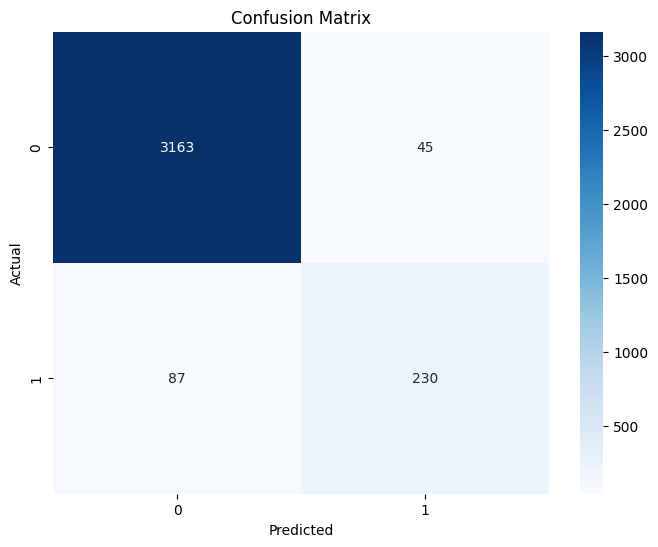

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3208
           1       0.84      0.73      0.78       317

    accuracy                           0.96      3525
   macro avg       0.90      0.86      0.88      3525
weighted avg       0.96      0.96      0.96      3525

Accuracy: 0.9626


In [85]:
# Confusion Matrix
cm_RF = confusion_matrix(y_test, y_pred_RF)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_RF, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_RF))

# Accuracy score

accuracy = accuracy_score(y_test, y_pred_RF)
print(f"Accuracy: {accuracy:.4f}")

# Creating a Support Vector Machines Model

In [74]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

In [75]:
MMscaler = MinMaxScaler()

In [76]:
MMscaler.fit_transform(X_train)

array([[7.19178082e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        3.31288344e-01],
       [2.39726027e-02, 3.92314656e-03, 0.00000000e+00, 0.00000000e+00,
        4.29447853e-01],
       [9.79452055e-01, 2.22311639e-02, 0.00000000e+00, 0.00000000e+00,
        1.65644172e-01],
       ...,
       [7.53424658e-01, 1.92133588e-02, 0.00000000e+00, 0.00000000e+00,
        9.44785276e-01],
       [9.96575342e-01, 2.21406297e-01, 2.50000000e-01, 2.49620253e-01,
        7.36196319e-01],
       [8.56164384e-02, 5.02967508e-04, 0.00000000e+00, 0.00000000e+00,
        2.39263804e-01]])

In [77]:
MMscaler.transform(X_test)

array([[2.26027397e-01, 1.05623177e-02, 0.00000000e+00, 0.00000000e+00,
        3.06748466e-02],
       [1.88356164e-01, 5.02967508e-04, 0.00000000e+00, 0.00000000e+00,
        9.07975460e-01],
       [4.21232877e-01, 1.77044563e-02, 0.00000000e+00, 4.05063291e-01,
        7.36196319e-01],
       ...,
       [5.65068493e-01, 4.72789458e-03, 1.25000000e-01, 0.00000000e+00,
        7.42331288e-01],
       [3.42465753e-03, 1.17493210e-01, 0.00000000e+00, 0.00000000e+00,
        1.65644172e-01],
       [5.61643836e-01, 1.84086108e-02, 0.00000000e+00, 0.00000000e+00,
        9.44785276e-01]])

In [78]:
param_grid_svm = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'gamma': ['scale', 'auto']
}

In [79]:
grid_search_svm = GridSearchCV(estimator=SVC(),
param_grid = param_grid_svm,
cv=5,
scoring = "accuracy",
n_jobs=-1,
verbose = 1)

In [80]:
svm_clf = grid_search_svm.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


KeyboardInterrupt: 

In [ ]:
"""
Due to Run time problem the code is not executed
"""
y_test_pred_svm = svm_clf.predict(X_test)

###Results